In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# new merged data set

df_new = pd.read_csv("../data/merged_clean.csv")

In [3]:
pd.crosstab(df_new["covid_misinfo_belief"], df_new["trump_vote"], normalize="index")


# % voted for Trump by misinfo belief
df_new.groupby("covid_misinfo_belief")["trump_vote"].mean()
# 26% of "came about naturally" believers voted for Trump,
# 65% of "intentionally developed" believers voted for Trump

covid_misinfo_belief
0.0    0.261222
1.0    0.654049
Name: trump_vote, dtype: float64

In [4]:
# % voted for Trump by political affiliation and misinfo belief

df_new.groupby(["F_PARTYSUM_FINAL", "covid_misinfo_belief"])["trump_vote"].mean()

pd.crosstab(df_new["F_PARTYSUM_FINAL"], df_new["covid_misinfo_belief"], values=df_new["trump_vote"], aggfunc="mean")

covid_misinfo_belief,0.0,1.0
F_PARTYSUM_FINAL,,
DK/Refused/No lean,0.147059,0.409091
Dem/Lean Dem,0.015223,0.065574
Rep/Lean Rep,0.854783,0.949198


In [5]:
# raw numbers

pd.crosstab(df_new["F_PARTYSUM_FINAL"], df_new["covid_misinfo_belief"])

covid_misinfo_belief,0.0,1.0
F_PARTYSUM_FINAL,,
DK/Refused/No lean,65,42
Dem/Lean Dem,2942,495
Rep/Lean Rep,1351,869


**Plotting misinfo belief by political party**

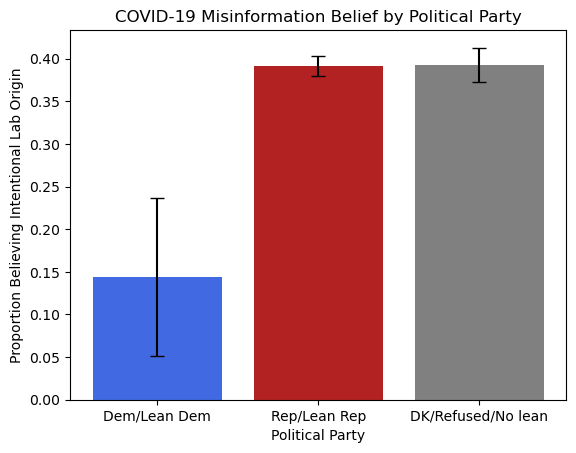

In [6]:
# proportion & count believing misinfo by party
misinfo_by_party = (df_new.groupby("F_PARTYSUM_FINAL")["covid_misinfo_belief"].mean().sort_values())
misinfo_n = (df_new.groupby("F_PARTYSUM_FINAL")["covid_misinfo_belief"].count())

# data for error bars
misinfo_se = np.sqrt(misinfo_by_party * (1 - misinfo_by_party) / misinfo_n)
misinfo_ci = 1.96 * misinfo_se

# different color for each bar
party_colors = {"Dem/Lean Dem": "royalblue", "Rep/Lean Rep": "firebrick", "DK/Refused/No lean": "grey"}
colors = [party_colors[party] for party in misinfo_by_party.index]


plt.bar(misinfo_by_party.index, misinfo_by_party.values, yerr=misinfo_ci.values, # error bars
        capsize=5, color=colors)
plt.xlabel("Political Party")
plt.ylabel("Proportion Believing Intentional Lab Origin")
plt.title("COVID-19 Misinformation Belief by Political Party")
plt.xticks(rotation=0)

plt.savefig("../output/misinfo_by_party.png",bbox_inches="tight")
plt.show()

**Plotting Trump voting by misinfo belief**

In [7]:
# proportion of each belief that voted for Trump
vote_by_misinfo = (df_new.groupby("covid_misinfo_belief")["trump_vote"].mean())
vote_by_misinfo

misinfo_n = df_new.groupby("covid_misinfo_belief")["trump_vote"].count()

# error bars
se = np.sqrt(vote_by_misinfo * (1 - vote_by_misinfo) / misinfo_n)
ci = 1.96 * se

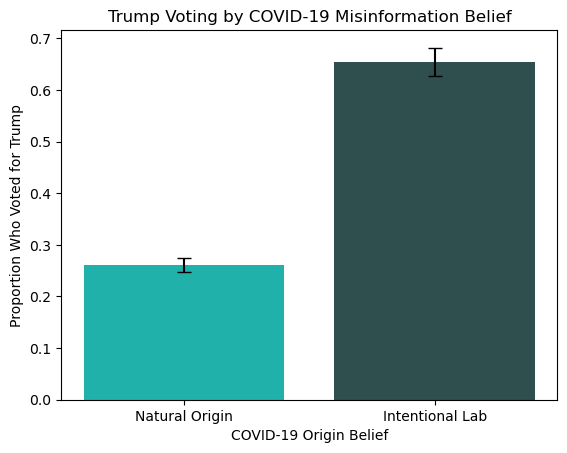

In [8]:
plt.bar(vote_by_misinfo.index, vote_by_misinfo.values, yerr=ci, capsize=5, color=["lightseagreen", "darkslategrey"])
plt.xlabel("COVID-19 Origin Belief")
plt.ylabel("Proportion Who Voted for Trump")
plt.title("Trump Voting by COVID-19 Misinformation Belief")
plt.xticks([0, 1], ["Natural Origin", "Intentional Lab"], rotation=0)

plt.savefig("../output/trump_vote_by_misinfo.png", bbox_inches="tight")
plt.show()

**Grouped bar chart - plotting Trump vote by misinfo belief within political party**

In [9]:
# proportion of Trump voters by political party and misinfo belief
party_vote = (df_new.groupby(["F_PARTYSUM_FINAL", "covid_misinfo_belief"])["trump_vote"].mean().unstack())
party_vote

party_n = (df_new.groupby(["F_PARTYSUM_FINAL", "covid_misinfo_belief"])["trump_vote"].count().unstack())

# error bars
party_se = np.sqrt(party_vote * (1 - party_vote) / party_n)
party_ci = 1.96 * party_se

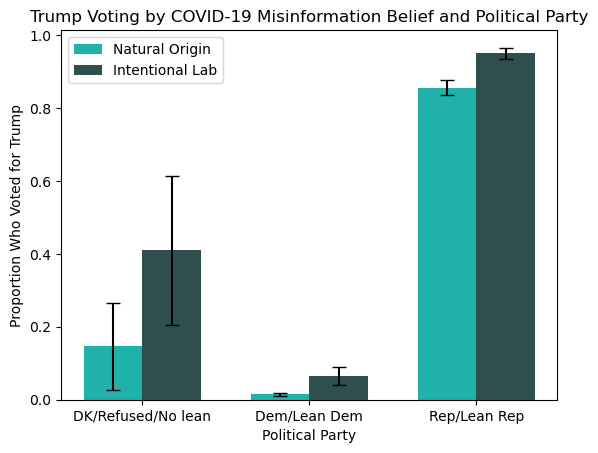

In [10]:
# position the two bars next to each other
x = np.arange(len(party_vote.index))
width = 0.35

# two sets of bars
plt.bar(x - width/2, party_vote[0.0], width, yerr=party_ci[0.0], capsize=5,label="Natural Origin", color="lightseagreen")
plt.bar(x + width/2, party_vote[1.0], width, yerr=party_ci[1.0], capsize=5,label="Intentional Lab", color="darkslategrey")

plt.xticks(x, party_vote.index)
plt.xlabel("Political Party")
plt.ylabel("Proportion Who Voted for Trump")
plt.title("Trump Voting by COVID-19 Misinformation Belief and Political Party")
plt.legend()

plt.savefig("../output/trump_vote_by_misinfo_party.png", bbox_inches="tight")
plt.show()